# 05 – Strategy Matrix
Run the full `StrategyMatrix` to score every strategy × every ticker,
visualise the heatmap, and automatically select the best combinations.

In [13]:
import sys
sys.path.insert(0, '..')

import logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s  %(message)s')

from strategy_matrix import StrategyMatrix

In [14]:
# ── Define your watchlist ────────────────────────────────────────────────────
# Mix of Irish/European and US liquid names
WATCHLIST = [
  #  'CRH.L',   # CRH (LSE)
    'SHEL.L',  # Shell (LSE)
    'AAPL',
    'MSFT',
    'NVDA',
]

matrix = StrategyMatrix(
    tickers=WATCHLIST,
    source='yfinance',
    period='2y',
    initial_capital=10_000,
    commission=0.001,
)
matrix.run()

INFO  Fetching data for SHEL.L …
INFO  Loading from cache: SHEL_L_2y_1d.csv
INFO  Fetching data for AAPL …
INFO  Loading from cache: AAPL_2y_1d.csv
INFO  Fetching data for MSFT …
INFO  Loading from cache: MSFT_2y_1d.csv
INFO  Fetching data for NVDA …
INFO  Loading from cache: NVDA_2y_1d.csv
INFO  Matrix complete: 5 strategies × 4 tickers


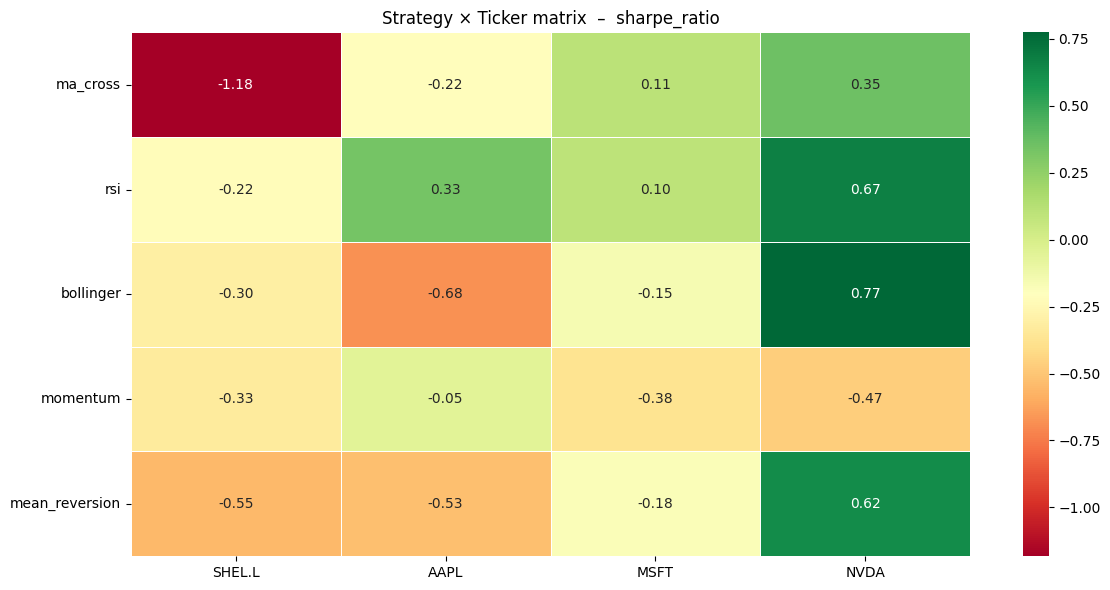

In [15]:
# Sharpe ratio heatmap
matrix.show('sharpe_ratio')

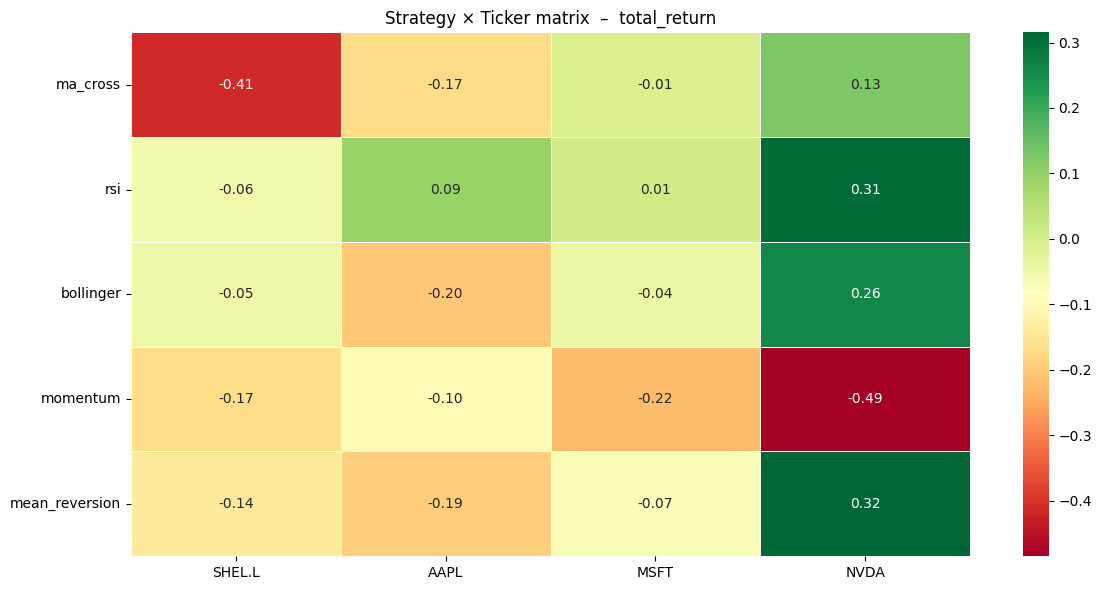

In [16]:
# Total return heatmap
matrix.show('total_return')

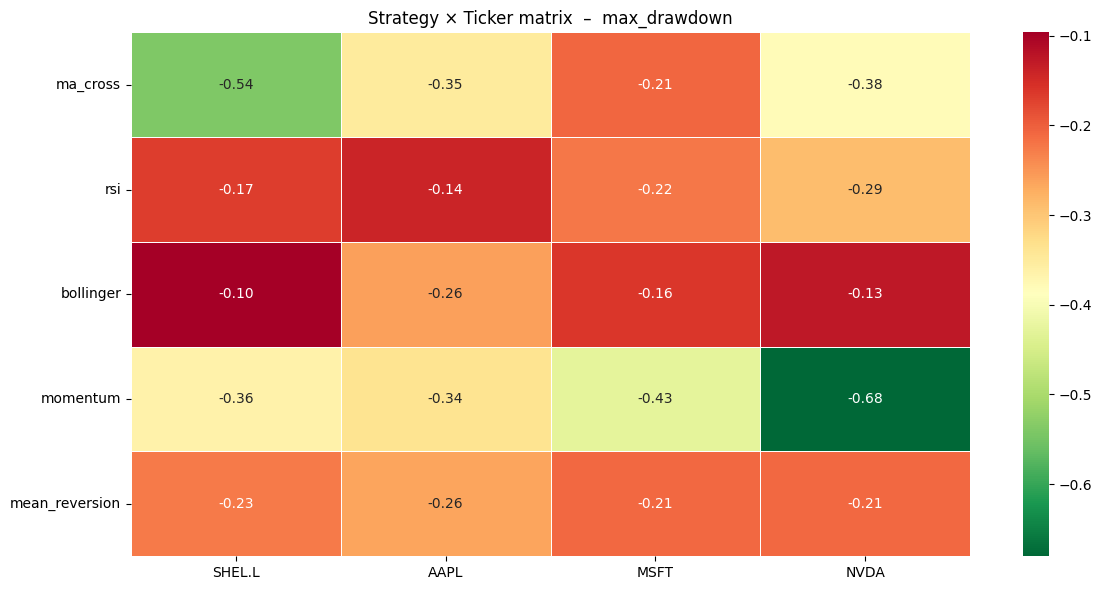

In [17]:
# Max drawdown heatmap (lower = better, reversed cmap)
matrix.show('max_drawdown', cmap='RdYlGn_r')

In [18]:
# Top 5 (strategy, ticker) combinations by Sharpe
print('=== Top 5 by Sharpe Ratio ===')
display(matrix.select_best('sharpe_ratio', top_n=5))

=== Top 5 by Sharpe Ratio ===


,strategy,ticker,sharpe_ratio
11,bollinger,NVDA,0.7741
7,rsi,NVDA,0.6705
19,mean_reversion,NVDA,0.6226
3,ma_cross,NVDA,0.3543
5,rsi,AAPL,0.3312


In [19]:
# Best strategy per ticker (interactive)
for ticker in WATCHLIST:
    ranked = matrix.select_for_ticker(ticker, 'sharpe_ratio')
    print(f'\n{ticker}:')
    print(ranked.to_string())


SHEL.L:
rsi              -0.2244
bollinger        -0.3042
momentum         -0.3288
mean_reversion   -0.5504
ma_cross         -1.1825

AAPL:
rsi               0.3312
momentum         -0.0529
ma_cross         -0.2166
mean_reversion   -0.5290
bollinger        -0.6812

MSFT:
ma_cross          0.1079
rsi               0.0990
bollinger        -0.1525
mean_reversion   -0.1802
momentum         -0.3753

NVDA:
bollinger         0.7741
rsi               0.6705
mean_reversion    0.6226
ma_cross          0.3543
momentum         -0.4665


In [20]:
# Full report: every combination with all metrics
report = matrix.full_report()
report.style.background_gradient(cmap='RdYlGn', subset=['sharpe_ratio', 'total_return'])